#Descargar y explorar Craigslist Vehicles Dataset


##Celda 1: Preparación del entorno y carga de datos
Esta celda crea la estructura de carpetas requerida (data/raw/) simulando un entorno de proyecto profesional dentro de Colab.

In [7]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import csv # Necesitas importar csv arriba

# Configuración visual para los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# NOTA: Antes de ejecutar esta línea, asegúrate de subir el archivo 'vehicles.csv'
# a la carpeta 'data/raw' en el panel de la izquierda de Google Colab.
file_path = 'vehicles.csv'


try:
    # Usamos engine='python' y on_bad_lines='skip' para ignorar filas malformadas
    df = pd.read_csv(file_path, engine='python', on_bad_lines='skip')
    print(f"Dataset cargado exitosamente. Dimensiones: {df.shape}")
except FileNotFoundError:
    print(f"Por favor, sube el archivo a la ruta {file_path}")

Dataset cargado exitosamente. Dimensiones: (123582, 26)


##Celda 2: Criterio de Aceptación - Tipos de Datos y Valores Nulos
Aquí analizaremos los tipos de variables y cuantificaremos la cantidad de datos faltantes, lo cual es crítico dado el snippet de datos que compartiste (lleno de comas vacías).

In [8]:
# --- TIPOS DE DATOS ---
print("--- TIPOS DE DATOS ---")
display(df.info())

# --- VALORES NULOS ---
print("\n--- REPORTE DE VALORES NULOS ---")
nulos = df.isnull().sum()
porcentaje_nulos = (nulos / len(df)) * 100
df_nulos = pd.DataFrame({'Valores Faltantes': nulos, 'Porcentaje (%)': porcentaje_nulos})

# Mostramos solo las columnas que tienen algún valor nulo ordenadas de mayor a menor
display(df_nulos[df_nulos['Valores Faltantes'] > 0].sort_values(by='Porcentaje (%)', ascending=False))

--- TIPOS DE DATOS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123582 entries, 0 to 123581
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            123582 non-null  int64  
 1   url           123582 non-null  object 
 2   region        123582 non-null  object 
 3   region_url    123582 non-null  object 
 4   price         123582 non-null  int64  
 5   year          123132 non-null  float64
 6   manufacturer  117993 non-null  object 
 7   model         122008 non-null  object 
 8   condition     76055 non-null   object 
 9   cylinders     73160 non-null   object 
 10  fuel          122873 non-null  object 
 11  odometer      121824 non-null  float64
 12  title_status  120956 non-null  object 
 13  transmission  122903 non-null  object 
 14  VIN           77605 non-null   object 
 15  drive         85171 non-null   object 
 16  size          35878 non-null   object 
 17  type          99025 non-n

None


--- REPORTE DE VALORES NULOS ---


,Valores Faltantes,Porcentaje (%)
county,123582,100.000000
size,87704,70.968264
cylinders,50422,40.800440
condition,47527,38.457866
VIN,45977,37.203638
drive,38411,31.081387
paint_color,36454,29.497823
type,24557,19.871017
manufacturer,5589,4.522503
title_status,2626,2.124905


#Celda 3: Limpieza Básica (Crucial antes de graficar)
Si intentas graficar el precio u odómetro crudo, el gráfico se distorsionará por autos que cuestan $0 o $99,999,999.

In [9]:
# Creamos una copia para el análisis limpio
df_clean = df.copy()

# 1. Eliminar valores atípicos (outliers) en precios
# Consideramos autos entre $500 y $100,000 para un mercado regular
df_clean = df_clean[(df_clean['price'] > 500) & (df_clean['price'] < 100000)]

# 2. Filtrar años ilógicos y eliminar nulos en 'year'
df_clean = df_clean.dropna(subset=['year'])
df_clean = df_clean[(df_clean['year'] >= 1990) & (df_clean['year'] <= 2024)]

# 3. Filtrar odómetros ilógicos y eliminar nulos en 'odometer'
df_clean = df_clean.dropna(subset=['odometer'])
df_clean = df_clean[df_clean['odometer'] <= 350000] # Menos de 350k millas

# 4. Eliminar nulos en marca y modelo para las visualizaciones
df_clean = df_clean.dropna(subset=['manufacturer', 'model'])

print(f"Dimensiones después de limpieza básica: {df_clean.shape}")
print(f"Se descartaron {len(df) - len(df_clean)} registros con errores, nulos o valores atípicos.")

Dimensiones después de limpieza básica: (100625, 26)
Se descartaron 22957 registros con errores, nulos o valores atípicos.


#Celda 4: Criterio de Aceptación - Distribuciones (Precio, Año, Odómetro)
Variables numéricas continuas o temporales.

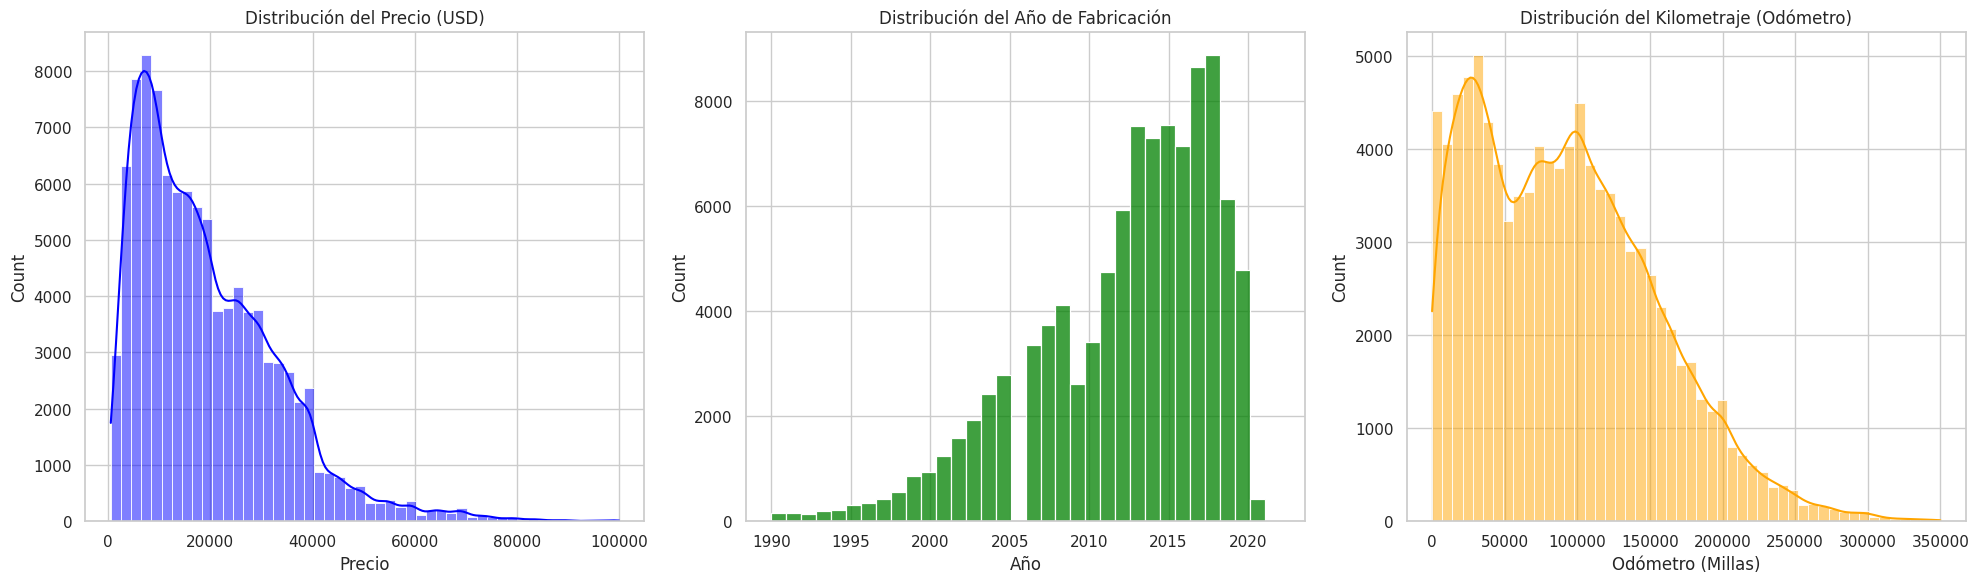

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Distribución del Precio
sns.histplot(df_clean['price'], bins=50, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribución del Precio (USD)')
axes[0].set_xlabel('Precio')

# Distribución del Año
sns.histplot(df_clean['year'], bins=34, kde=False, ax=axes[1], color='green')
axes[1].set_title('Distribución del Año de Fabricación')
axes[1].set_xlabel('Año')

# Distribución del Odómetro (Millas)
sns.histplot(df_clean['odometer'], bins=50, kde=True, ax=axes[2], color='orange')
axes[2].set_title('Distribución del Kilometraje (Odómetro)')
axes[2].set_xlabel('Odómetro (Millas)')

plt.tight_layout()
plt.show()

#Celda 5: Criterio de Aceptación - Distribuciones (Marca y Modelo)
Como hay demasiadas marcas y modelos, graficar todo es imposible. Graficaremos el Top 20.

/tmp/ipykernel_2148/3759378529.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_marcas.values, y=top_marcas.index, ax=axes[0], palette="viridis")
/tmp/ipykernel_2148/3759378529.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_modelos.values, y=top_modelos.index, ax=axes[1], palette="magma")


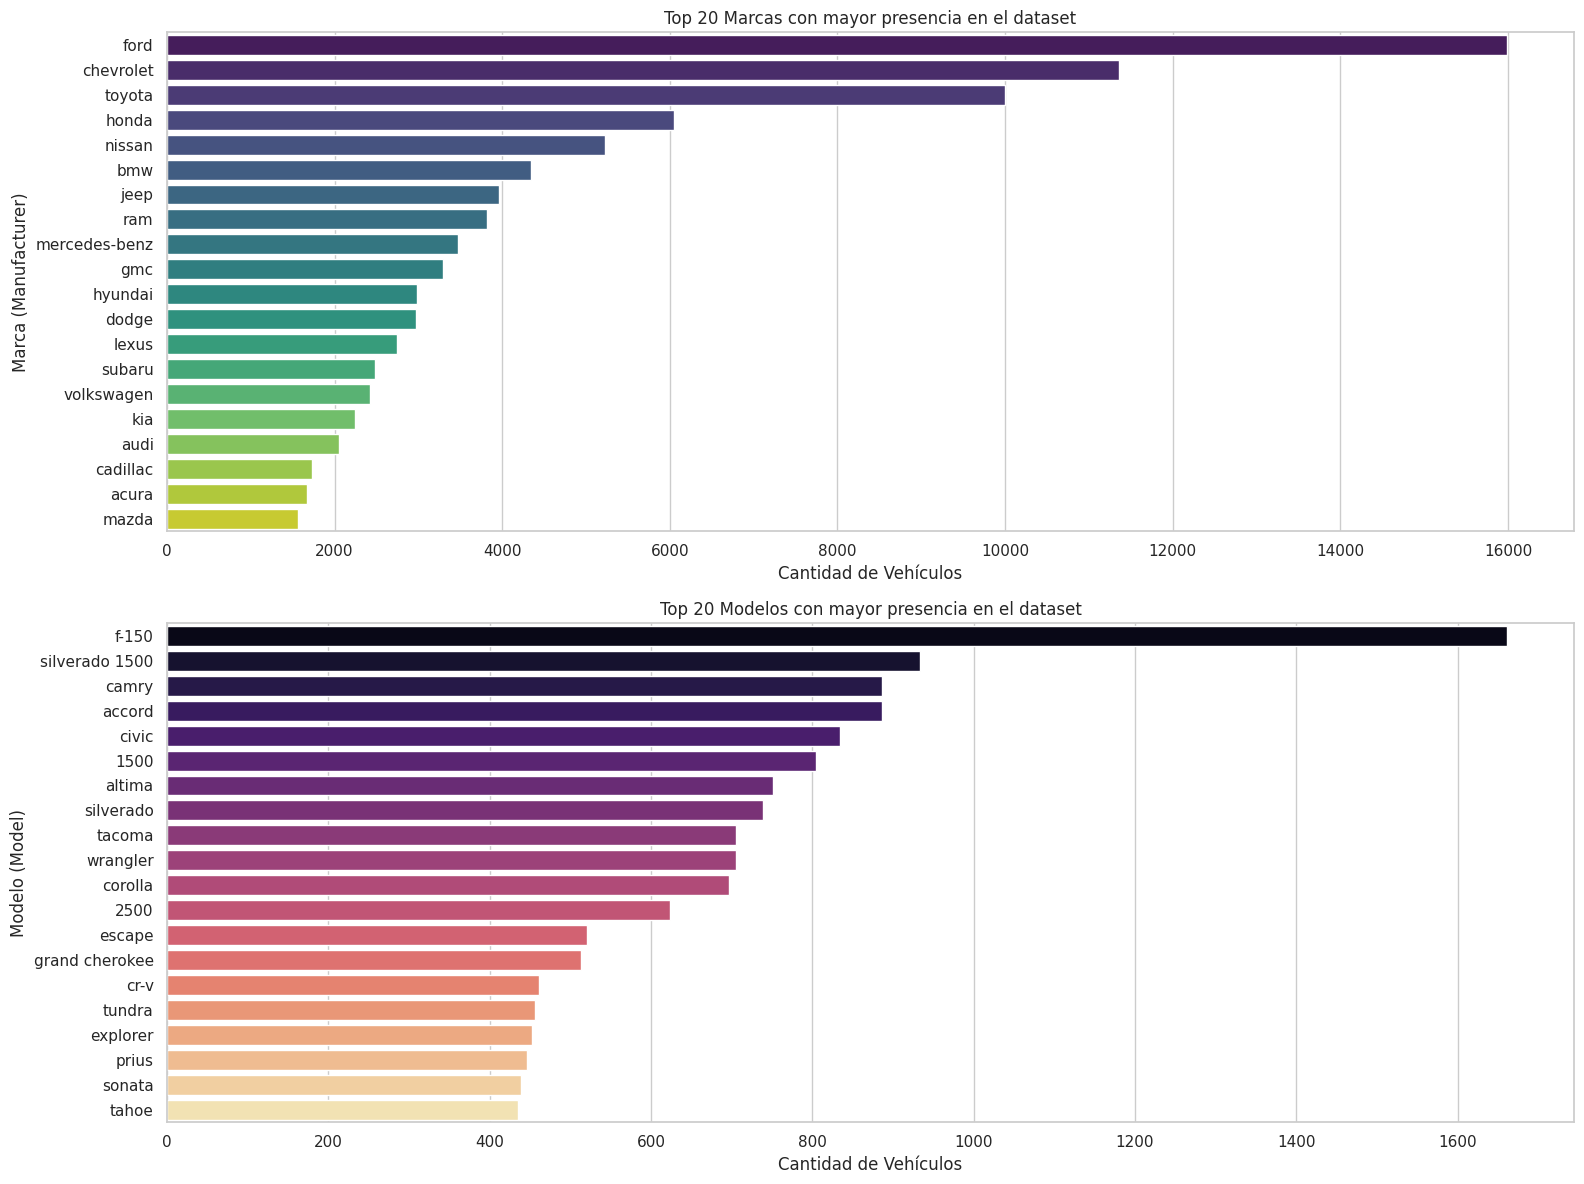

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# 1. Distribución de Marcas (Top 20)
top_marcas = df_clean['manufacturer'].value_counts().head(20)
sns.barplot(x=top_marcas.values, y=top_marcas.index, ax=axes[0], palette="viridis")
axes[0].set_title('Top 20 Marcas con mayor presencia en el dataset')
axes[0].set_xlabel('Cantidad de Vehículos')
axes[0].set_ylabel('Marca (Manufacturer)')

# 2. Distribución de Modelos (Top 20)
top_modelos = df_clean['model'].value_counts().head(20)
sns.barplot(x=top_modelos.values, y=top_modelos.index, ax=axes[1], palette="magma")
axes[1].set_title('Top 20 Modelos con mayor presencia en el dataset')
axes[1].set_xlabel('Cantidad de Vehículos')
axes[1].set_ylabel('Modelo (Model)')

plt.tight_layout()
plt.show()

#Celda 6: Exportación y descarga del dataset limpio
Como buena práctica en proyectos de Data Science, guardaremos este archivo limpio en una nueva carpeta llamada data/processed/ (datos procesados) para no sobrescribir tus datos crudos (data/raw/). Finalmente, usaremos la librería nativa de Colab para forzar la descarga automática del nuevo archivo .csv a tu computadora.

In [12]:
import os
from google.colab import files

# 1. Crear carpeta para datos procesados (buenas prácticas)
os.makedirs('data/processed', exist_ok=True)

# 2. Definir la ruta del nuevo archivo
cleaned_file_path = 'data/processed/vehicles_clean.csv'

# 3. Guardar el DataFrame limpio en un nuevo archivo CSV
# index=False evita que se guarde la columna de índices de Pandas
df_clean.to_csv(cleaned_file_path, index=False)
print(f"Dataset limpio guardado exitosamente en: {cleaned_file_path}")
print(f"Tamaño del nuevo dataset: {df_clean.shape}")

# 4. Descargar el archivo automáticamente a tu computadora
files.download(cleaned_file_path)

Dataset limpio guardado exitosamente en: data/processed/vehicles_clean.csv
Tamaño del nuevo dataset: (100625, 26)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>